In [1]:
import numpy as np
import pandas as pd
import scipy
import time
import sys
sys.path.append('../sourcing_models/')
import matplotlib.pyplot as plt
from lib.dual_sourcing import *

from copy import deepcopy
from collections import Counter
from scipy.stats import truncnorm
from matplotlib import rcParams
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

# customized settings
params = {  # 'backend': 'ps',
    'font.family': 'serif',
    'font.serif': 'Fira',
    'font.size': 10,
    'axes.labelsize': 'medium',
    'axes.titlesize': 'medium',
    'legend.fontsize': 'medium',
    'xtick.labelsize': 'small',
    'ytick.labelsize': 'small',
    'savefig.dpi': 150,
    'text.usetex': True}
# tell matplotlib about your params
rcParams.update(params)

# set nice figure sizes
fig_width_pt = 245    # Get this from LaTeX using \showthe\columnwidth
golden_mean = (np.sqrt(5.) - 1.) / 2.  # Aesthetic ratio
ratio = golden_mean
inches_per_pt = 1. / 72.27  # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt  # width in inches
fig_height = fig_width*ratio  # height in inches
fig_size = [fig_width, fig_height]
rcParams.update({'figure.figsize': fig_size})

# Load data
We first load the data that was published along with the MSOM article "Data Set: 187 Weeks of Customer Forecasts and Orders for Microprocessors from Intel Corporation".

In [2]:
data = pd.read_csv("msom.2020.0933.csv")
max_weeks = max(data["Week"].to_numpy())
max_weeks = 115
X = np.arange(1,max_weeks+1)

Next, we select the relevant stock keeping units (SKUs) and customer orders.

In [3]:
def select_SKUs(SKUs):
    
    y = []
    for SKU in SKUs:
        
        data_ = data[data["SKU"] == SKU]
        weeks = data_[data_["SKU"] == SKU]["Week"].to_numpy()
        orders = data_[data_["SKU"] == SKU]["Customer Orders"].to_numpy()
        data_["Total Customer Orders"] = data_.groupby(["Week"])['Customer Orders'].transform('sum')
        total_orders = data_["Total Customer Orders"].to_numpy()
        
        weeks_total_orders = sorted(set([(x[0],x[1]) for x in zip(weeks,total_orders)]))
        
        weeks_ = np.array([x[0] for x in weeks_total_orders])
        total_orders_ = np.array([x[1] for x in weeks_total_orders])
        
        y_ = []
        for i in range(len(X)):
            
            if X[i] in weeks_:
                y_.append(total_orders_[X[i] == weeks_][0])
            else:
                y_.append(np.nan)
        
        y.append(np.array(y_))
    
    return np.array(y)

We select third generation SKUs.

In [4]:
#SKUs = ["SKU-A-2", "SKU-B-2", "SKU-C-1", "SKU-C-2", "SKU-F-1", "SKU-F-2", "SKU-H-2", "SKU-I-2", "SKU-J-2", "SKU-K-2", "SKU-L-1", "SKU-L-2", "SKU-M-2", "SKU-O-1", "SKU-O-2", "SKU-Q-2", "SKU-S-2"]
SKUs = ["SKU-A-3", "SKU-B-3", "SKU-C-3", "SKU-E-3", "SKU-H-3", "SKU-I-3", "SKU-J-3", "SKU-N-3", "SKU-S-3", "SKU-T-3"]
y = select_SKUs(SKUs)

/home/lucasb/anaconda3/envs/inventory/lib/python3.6/site-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if __name__ == '__main__':


In [5]:
y_impute = np.nan_to_num(y,nan=0)
max_y = np.max(y_impute)

# Model data by Gaussian process

We now determine the means and standard deviations separately for all weeks.

In [6]:
mean_arr = np.array([np.mean(y_impute[:,i]/1e5) for i in range(len(X))])
std_arr = np.array([np.std(y_impute[:,i]/1e5,ddof=1) for i in range(len(X))])

Plot the original data, mean, and 95% confidence interval.

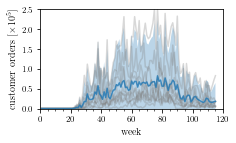

In [7]:
fig, ax = plt.subplots(facecolor='white')
for i in range(len(SKUs)):
    plt.plot(X, y_impute[i]/1e5,alpha=0.3,color='Grey')
plt.plot(X,mean_arr,color='tab:blue',alpha=0.8)
plt.fill_between(X,mean_arr+1.96*std_arr,mean_arr-1.96*std_arr,alpha=0.3)
ax.xaxis.set_minor_locator(MultipleLocator(5))
plt.xlim(0,120)
plt.ylim(0,2.5)
plt.xlabel(r"week")
plt.ylabel(r"customer orders [$\times 10^5$]")
plt.tight_layout()
plt.savefig("gaussian_sampling.png",dpi=480)
plt.show()

Generate samples using a truncated normal distribution.

In [8]:
num_samples = 1000
samples = []
myclip_a = 0
myclip_b = 1e3

for i in range(len(mean_arr)):
    
    my_mean = mean_arr[i]
    my_std = std_arr[i]
    a, b = (myclip_a - my_mean) / (1e-9+my_std), (myclip_b - my_mean) / (1e-9+my_std)
    r = truncnorm.rvs(a, b, loc=my_mean, scale=my_std, size=num_samples)
    samples.append(r)

/home/lucasb/anaconda3/envs/inventory/lib/python3.6/site-packages/scipy/stats/_distn_infrastructure.py:1760: RuntimeWarning: divide by zero encountered in true_divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/home/lucasb/anaconda3/envs/inventory/lib/python3.6/site-packages/scipy/stats/_distn_infrastructure.py:1760: RuntimeWarning: invalid value encountered in true_divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/home/lucasb/anaconda3/envs/inventory/lib/python3.6/site-packages/scipy/stats/_distn_infrastructure.py:1760: RuntimeWarning: divide by zero encountered in true_divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/home/lucasb/anaconda3/envs/inventory/lib/python3.6/site-packages/scipy/stats/_distn_infrastructure.py:1760: RuntimeWarning: invalid value encountered in true_divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/home/lucasb/anaconda3/envs/inventory/lib/python3.6/site-packages/scipy/stats/_distn_infrastructure.py:1760: RuntimeWarning: divide by zero encountere

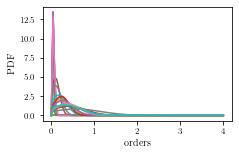

In [9]:
x = np.linspace(0,4,100)
plt.figure()
for i in range(40):
    myclip_a = 0
    myclip_b = 1e2
    my_mean = mean_arr[i]
    my_std = std_arr[i]
    a, b = (myclip_a - my_mean) / (1e-9+my_std), (myclip_b - my_mean) / (1e-9+my_std)
    rv = truncnorm(a, b, loc=my_mean, scale=my_std)
    r = lambda x: rv.pdf(x)
    plt.plot(x,r(x))
plt.xlabel(r"orders")
plt.ylabel(r"PDF")
plt.show()

Compare original data and samples.

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


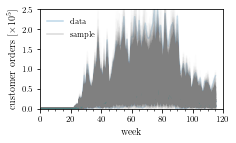

In [10]:
fig, ax = plt.subplots(facecolor="white")
for i in range(len(SKUs)):
    plt.plot(X, y_impute[i]/1e5,alpha=0.2,color="tab:blue")
plt.plot(X,samples,alpha=0.02,color="Grey")
plt.plot(100, 100,alpha=0.3,color="tab:blue",label="data")
plt.plot(100,100,alpha=0.3,color="Grey",label="sample")
ax.xaxis.set_minor_locator(MultipleLocator(5))
plt.xlim(0,120)
plt.ylim(0,2.5)
plt.xlabel(r"week")
plt.ylabel(r"customer orders [$\times 10^5$]")
plt.legend(loc=2,frameon=False,fontsize=8)
plt.tight_layout()
plt.savefig("gaussian_sampling_2.png",dpi=480)
plt.show()

# Apply CDI policy to empirical demand data

In [11]:
#np.random.seed(10)

ce = 20
cr = 0
le = 0
lr = 2
h = 5
b = 495

In [12]:
myclip_a = 0
myclip_b = 1e3
mean_arr = mean_arr
std_arr = std_arr
max_weeks = len(mean_arr)

#mean_arr = np.append(mean_arr,mean_arr)
#std_arr = np.append(std_arr,std_arr)
#max_weeks = 2*max_weeks

sampling_function = lambda i, num_samples: 1e5*truncnorm.rvs((myclip_a - mean_arr[i]) / (1e-9+std_arr[i]), 
                                                         (myclip_b - mean_arr[i]) / (1e-9+std_arr[i]), 
                                                         loc=mean_arr[i], scale=std_arr[i], 
                                                         size=num_samples)

In [13]:
def optimal_u1_func(h,
                    b,
                    D_low,
                    D_high):

    return (h*D_low+b*D_high)/(h+b)

def optimal_u2_func(h,
                    b,
                    D_low,
                    D_high,
                    L):
    
    return (h*D_low*L+b*D_high*L)/(h+b)

In [14]:
# determine optimal CDI parameters                             
optimal_u1 = [int(optimal_u1_func(h, b, \
             max(0,1e5*mean_arr[i]-2.58*1e5*std_arr[i]), \
             1e5*mean_arr[i]+2.58*1e5*std_arr[i])) \
             for i in range(len(mean_arr))]
optimal_u2 = [int(optimal_u2_func(h, b, \
             max(0,1e5*mean_arr[i]-2.58*1e5*std_arr[i]), \
             1e5*mean_arr[i]+2.58*1e5*std_arr[i], lr-le)) \
             for i in range(len(mean_arr))]
optimal_u3 = optimal_u2

In [15]:
cost_arr = []
I0 = 0
for i in range(1000):
        S = DualSourcingModel(ce=ce, 
                              cr=cr, 
                              le=le, 
                              lr=lr, 
                              h=h, 
                              b=b,
                              T=max_weeks, 
                              I0=I0,
                              u1=optimal_u1,
                              u2=optimal_u2,
                              u3=optimal_u3,
                              capped_dual_index=True,
                              demand_distribution=[sampling_function])

        S.simulate()
        cost_arr.append(S.total_cost)

In [16]:
print(np.mean(cost_arr)/max_weeks,np.std(cost_arr)/max_weeks)

778246.4785652173 55710.98871200424


# Compare CDI with NNC-based policies

Generate sampling function.

In [17]:
myclip_a = 0
myclip_b = 1e3
mean_arr = mean_arr
std_arr = std_arr
max_weeks = len(mean_arr)

#mean_arr = np.append(mean_arr,mean_arr)
#std_arr = np.append(std_arr,std_arr)
#max_weeks = 2*max_weeks

sampling_function = lambda i, num_samples: 1e5*truncnorm.rvs((myclip_a - mean_arr[i]) / (1e-9+std_arr[i]), 
                                                         (myclip_b - mean_arr[i]) / (1e-9+std_arr[i]), 
                                                         loc=mean_arr[i], scale=std_arr[i], 
                                                         size=num_samples)

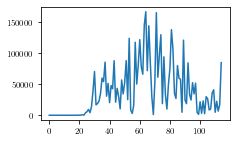

In [18]:
plt.figure()
plt.plot([np.mean(sampling_function(i,1)) for i in range(max_weeks)])
plt.show()

In [615]:
sourcing_parameters = dict(ce=20,
                           cr=0,
                           le=0,
                           lr=2,
                           h=5,
                           b=495,
                           T=max_weeks,
                           demand_distribution=[sampling_function])    

## NNC Initialization
Here we initialize an NNC model and set  its hyperparameters for training.

In [616]:
import sys
sys.path.append('../')
import torch
from neural_control.controllers import DualFullyConnectedRegressionControllerTime
from neural_control.dynamics import DualSourcingModel
from copy import deepcopy
from sourcing_models.utilities import sample_trajectories_capped_dual_index_temporal, \
sample_trajectories_dual_index, sample_trajectories_single_index, sample_trajectories_tailored_base_surge

In [617]:
### One can experiment with different layer architectures and activations per layer
nnc_hyperparameters = dict(
    n_hidden_units = [8,8,8]
)

### We use celu non-linearities for the input layer, hidden layers, and output layer
nnc_hyperparameters['n_activations'] = [torch.nn.CELU(alpha=0.1)]*(2 + len(nnc_hyperparameters['n_hidden_units']))


fcc = DualFullyConnectedRegressionControllerTime(
                                         lr=sourcing_parameters['lr'], 
                                         le=sourcing_parameters['le'], 
                                         n_hidden_units= nnc_hyperparameters ['n_hidden_units'],
                                         activations=nnc_hyperparameters['n_activations']
                                        ) # controller neural network object


## Dynamics Initialization
To further optimize NNC (''fine tuning''), we now apply gradient propagation to the inventory evolution equation:

$I_t = I_{t-1} + q^{\rm e}_{t-l_{\rm e}} + q^{\rm r}_{t-l_{\rm r}} - D_t$

where $I_0, q^{\rm e}_{t},q^{\rm r}_{t}$ are NNC outputs.

In [618]:
dsd = DualSourcingModel(fcc, I_0=1e0, **sourcing_parameters) # Dual Sourcing Dynamics object

We preserve the best performing model in training, assuming that the neural network generalizes well during training and that our training sample is large enough.

In [619]:
best_loss = [np.infty]
best_model = [None]

In [620]:
all_training_costs = []

In [621]:
optimizer = torch.optim.RMSprop(#[dsd.I_0],
                                list(fcc.parameters()), 
                                lr=3e-3)
                               
optimizer2 = torch.optim.RMSprop([dsd.I_0],
                                #list(fcc.parameters()), 
                                lr=1e-1
                               )

In [622]:
fine_tuning_iterations = 3000
minibatch_size = 1
random_seed = 4

t0 = time.time()
for it in range(fine_tuning_iterations):
    optimizer.zero_grad()
    optimizer2.zero_grad()
    def closure():
        dsd.reset(minibatch_size, seed=random_seed)
        total_costs = 0
        for i in range(dsd.T):
            current_costs, demands, current_inventories, qr, qra, qe, qea = dsd.simulate(1e5*mean_arr[i],1e5*std_arr[i])
            total_costs = current_costs.mean() + total_costs #1e1*sourcing_parameters["ce"]*int(sum(qea))
        all_training_costs.append(float(total_costs)/dsd.T)
        total_costs.backward()
        if it % 20 == 0:
            print(total_costs/dsd.T)
        if total_costs < best_loss[0]:
            best_loss[0] = total_costs.detach().cpu().item()
            best_model[0] = deepcopy(fcc.state_dict())
        return total_costs
    
    if best_loss[0]/dsd.T < 8e5:
        break
    if it % 10 > 6:
        optimizer2.step(closure)
    else:
        optimizer.step(closure)
t1 = time.time()
total = t1-t0
print(total)

tensor(6.9957e+08, grad_fn=<DivBackward0>)
tensor(28141454., grad_fn=<DivBackward0>)
tensor(7226449.5000, grad_fn=<DivBackward0>)
tensor(5545680., grad_fn=<DivBackward0>)
tensor(4477671., grad_fn=<DivBackward0>)
tensor(3737802.7500, grad_fn=<DivBackward0>)
tensor(3112266.2500, grad_fn=<DivBackward0>)
tensor(2730545.7500, grad_fn=<DivBackward0>)
tensor(2504665., grad_fn=<DivBackward0>)
tensor(2355411.2500, grad_fn=<DivBackward0>)
tensor(2196395.2500, grad_fn=<DivBackward0>)
tensor(2058147., grad_fn=<DivBackward0>)
tensor(1992583., grad_fn=<DivBackward0>)
tensor(1957044., grad_fn=<DivBackward0>)
tensor(1929262., grad_fn=<DivBackward0>)
tensor(1911675.1250, grad_fn=<DivBackward0>)
tensor(1895986.5000, grad_fn=<DivBackward0>)
tensor(1876096.5000, grad_fn=<DivBackward0>)
tensor(1857520., grad_fn=<DivBackward0>)
tensor(1834105.1250, grad_fn=<DivBackward0>)
tensor(1812571.2500, grad_fn=<DivBackward0>)
tensor(1790248.8750, grad_fn=<DivBackward0>)
tensor(1767199.8750, grad_fn=<DivBackward0>)
te

In [623]:
optimizer = torch.optim.RMSprop(#[dsd.I_0],
                                list(fcc.parameters()), 
                                lr=2e-4)
                               
optimizer2 = torch.optim.RMSprop([dsd.I_0],
                                #list(fcc.parameters()), 
                                lr=1e-1
                               )

In [624]:
fine_tuning_iterations = 3000
minibatch_size = 1
random_seed = 4

t0 = time.time()
for it in range(fine_tuning_iterations):
    optimizer.zero_grad()
    optimizer2.zero_grad()
    def closure():
        dsd.reset(minibatch_size, seed=random_seed)
        total_costs = 0
        for i in range(dsd.T):
            current_costs, demands, current_inventories, qr, qra, qe, qea = dsd.simulate(1e5*mean_arr[i],1e5*std_arr[i])
            total_costs = current_costs.mean() + total_costs #1e1*sourcing_parameters["ce"]*int(sum(qea))
        all_training_costs.append(float(total_costs)/dsd.T)
        total_costs.backward()
        if it % 20 == 0:
            print(total_costs/dsd.T)
        if total_costs < best_loss[0]:
            best_loss[0] = total_costs.detach().cpu().item()
            best_model[0] = deepcopy(fcc.state_dict())
        return total_costs
    
    if best_loss[0]/dsd.T < 6.5e5:
        break    
    if it % 10 > 6:
        optimizer2.step(closure)
    else:
        optimizer.step(closure)
t1 = time.time()
total = t1-t0
print(total)

tensor(814614.8750, grad_fn=<DivBackward0>)
tensor(788663.8125, grad_fn=<DivBackward0>)
tensor(777314., grad_fn=<DivBackward0>)
tensor(779600.1875, grad_fn=<DivBackward0>)
tensor(775691.4375, grad_fn=<DivBackward0>)
tensor(775256.5000, grad_fn=<DivBackward0>)
tensor(766147.4375, grad_fn=<DivBackward0>)
tensor(766225.1250, grad_fn=<DivBackward0>)
tensor(763074.2500, grad_fn=<DivBackward0>)
tensor(762239.2500, grad_fn=<DivBackward0>)
tensor(761752.0625, grad_fn=<DivBackward0>)
tensor(758447.4375, grad_fn=<DivBackward0>)
tensor(757153.6875, grad_fn=<DivBackward0>)
tensor(758258.8125, grad_fn=<DivBackward0>)
tensor(753977., grad_fn=<DivBackward0>)
tensor(754342.3125, grad_fn=<DivBackward0>)
tensor(759193.2500, grad_fn=<DivBackward0>)
tensor(753303.5000, grad_fn=<DivBackward0>)
tensor(751973.7500, grad_fn=<DivBackward0>)
tensor(753089., grad_fn=<DivBackward0>)
tensor(751268.3125, grad_fn=<DivBackward0>)
tensor(749132.1250, grad_fn=<DivBackward0>)
tensor(753924.6875, grad_fn=<DivBackward0>)


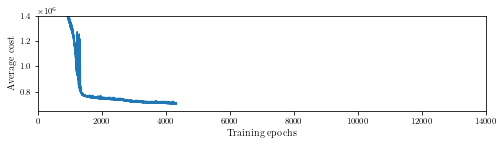

In [625]:
from matplotlib.ticker import NullFormatter

# set nice figure sizes
fig_width_pt = 495    # Get this from LaTeX using \showthe\columnwidth
golden_mean = (np.sqrt(5.) - 1.) / 2.  # Aesthetic ratio
ratio = golden_mean
inches_per_pt = 1. / 72.27  # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt  # width in inches
fig_height = fig_width*ratio  # height in inches
fig_size = [fig_width, 0.5*fig_height]
rcParams.update({'figure.figsize': fig_size})

costs = np.array(all_training_costs)
#np.savetxt("cost_direct_learning.dat",costs)

fig, ax = plt.subplots(ncols=1)
plt.plot(costs,alpha=1)
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_xlabel(r'Training epochs')
ax.set_ylabel(r'Average cost')
plt.tight_layout()
#plt.yscale("log")
plt.xlim(0,14000)
plt.ylim(6.5e5,1.4e6)
plt.margins(0,0)
plt.show()

In [572]:
fcc.load_state_dict(best_model[0])
#best_model_load = torch.load('nnc_best_model_MSOM_091921.pt', map_location='cpu')
#fcc.load_state_dict(best_model_load)

<All keys matched successfully>

In [626]:
min(costs)

701643.6869565217

In [574]:
#torch.save(best_model[0], '/home/lucasb/Documents/nnc_best_model_MSOM_110421.pt')

## Comparison 
First, we generate new dual-index samples.
These will be used to compare performance on unseen samples for NNC.

In [627]:
sourcing_parameters = dict(ce=20,
                           cr=0,
                           le=0,
                           lr=2,
                           h=5,
                           b=495,
                           T=max_weeks,
                           I0=1,
                           demand_distribution=[sampling_function])

state_trajectories, qr_trajectories, qe_trajectories =\
    sample_trajectories_capped_dual_index_temporal(n_trajectories=1000, mean_demand_arr=1e5*mean_arr, std_demand_arr=1e5*std_arr, seed=25, **sourcing_parameters)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 321, 321, 1312, 7201, 11940, 11482, 33933, 12631, 43658, 84040, 63217, 124132, 89857, 69360, 67913, 85442, 139436, 108026, 205949, 121092, 124953, 85321, 139406, 98198, 179131, 87242, 73189, 107380, 133762, 153760, 188938, 195145, 207978, 167576, 220560, 243182, 169347, 184852, 126285, 140810, 221677, 192560, 238256, 227933, 183789, 228725, 185698, 188154, 224006, 222152, 193653, 192244, 203762, 210757, 216014, 260674, 159028, 267070, 205060, 227624, 177679, 153040, 271694, 193028, 167711, 183751, 220326, 245496, 231750, 169770, 235478, 138734, 95527, 97251, 136061, 58963, 117105, 102469, 104136, 52276, 69467, 97077, 102344, 83181, 70602, 76902, 59069, 44223, 72177, 82811, 82379, 65781, 48334, 57937, 68741, 78094]


In [628]:
dsd.reset(1)
def evaluate_nnc_on_sample(state_trajectories, 
                           sample_id):
    
    fixed_demands = state_trajectories[sample_id, 1:, 1].unsqueeze(-1)

    nn_inv = dsd.learned_I_0.detach().clone()
    dsd.reset(1)
    nn_qr = [torch.zeros([1,1])]*(dsd.lr+1)
    nn_qe = [torch.zeros([1,1])]*(dsd.le+1)
    nn_ci = []
    all_nn_inv = [nn_inv.item()]
    D = torch.tensor(0.0).unsqueeze(0).unsqueeze(0)
    for i in range(sourcing_parameters["T"]):
        qr, qe = fcc(D, nn_inv, nn_qr, nn_qe, 1e5*mean_arr[i],1e5*std_arr[i])
        D = fixed_demands[i].unsqueeze(0)
        nn_qr.append(qr)
        nn_qe.append(qe)
        qra = nn_qr[-dsd.lr-1]
        qea = nn_qe[-dsd.le-1]
        c_i, nn_inv = dsd.replay_step(nn_inv, D, qra, qea, qr, qe)
        nn_ci.append(c_i)
        all_nn_inv.append(nn_inv.item())
    return all_nn_inv, nn_qr, nn_qe, nn_ci, torch.stack(nn_ci).mean()

In [629]:
def evaluate_cdi_on_sample(state_trajectories, 
                           qr_trajectories, 
                           qe_trajectories, 
                           sample_id):
    
    dsd.reset(1)
    fixed_demands = state_trajectories[sample_id, 1:, 1].unsqueeze(-1)

    ds_inv = state_trajectories[sample_id, 0, 0].unsqueeze(0).unsqueeze(0)
    dsd.reset(1)
    all_qr = [0]*dsd.lr
    all_qe = [0]*dsd.le
    all_ci = []
    all_inv = [ds_inv.detach().item()]
    for i in range(sourcing_parameters["T"]):
        D = fixed_demands[i].unsqueeze(0)
        if dsd.le == 0:
            qe = qe_trajectories[sample_id, i+1]
        else:
            qe = qe_trajectories[sample_id, dsd.le+i]
    
        if dsd.lr == 0:
            qr = qr_trajectories[sample_id, i+1]
        else:
            qr = qr_trajectories[sample_id, dsd.lr+i]
            
        all_qr.append(qr)
        all_qe.append(qe)
        qra = all_qr[-dsd.lr-1]
        qea = all_qe[-dsd.le-1]
        #if i == 50:
            #print(qra, qea, ds_inv, D)
        c_i, ds_inv = dsd.replay_step(ds_inv, D, qra, qea, qr, qe)
        all_inv.append(ds_inv.detach().item())
        all_ci.append(c_i)
    # test if calculated inventories and costs are the same as the ones reported
    # from the dual sourcing code
    assert torch.all(torch.tensor(all_inv) == state_trajectories[sample_id, :, 0])
    assert torch.all(torch.tensor(all_ci) == state_trajectories[sample_id, 1:, -1])
    return all_inv, all_qr, all_qe, all_ci, torch.stack(all_ci).float().mean()

In [630]:
cost_ratios = []
cost_nn = []
cost_cdi = []

samples = 1000
for i in range(samples):
    print("%d/%d samples completed"%(i,samples))
    nn_inv, nn_qr, nn_qe, nn_ci, nn_mean_cost = evaluate_nnc_on_sample(state_trajectories, 
                                                                       i)
    
    cdi_inv, cdi_qr, cdi_qe, cdi_ci, cdi_mean_cost = evaluate_cdi_on_sample(state_trajectories, 
                                                                            qr_trajectories, 
                                                                            qe_trajectories, 
                                                                            i)
    cost_nn.append(nn_mean_cost.detach().item())
    cost_cdi.append(cdi_mean_cost.detach().item())
    print("NN cost/CDI cost:", nn_mean_cost.detach().item()/cdi_mean_cost.detach().item())
    cost_ratios.append(nn_mean_cost.detach().item()/cdi_mean_cost.detach().item())

print("mean CDI:", np.mean(cost_cdi))
print("mean NNC:", np.mean(cost_nn))

0/1000 samples completed
NN cost/CDI cost: 0.8836871953635004
1/1000 samples completed
NN cost/CDI cost: 0.8505861561692406
2/1000 samples completed
NN cost/CDI cost: 0.8162448035430575
3/1000 samples completed
NN cost/CDI cost: 1.118533022306599
4/1000 samples completed
NN cost/CDI cost: 0.9975612759497037
5/1000 samples completed
NN cost/CDI cost: 1.021448059929891
6/1000 samples completed
NN cost/CDI cost: 1.0835676323218923
7/1000 samples completed
NN cost/CDI cost: 1.7094861356122353
8/1000 samples completed
NN cost/CDI cost: 0.8664023318709702
9/1000 samples completed
NN cost/CDI cost: 0.8972055574375007
10/1000 samples completed
NN cost/CDI cost: 1.1794224060727665
11/1000 samples completed
NN cost/CDI cost: 0.9260041846249814
12/1000 samples completed
NN cost/CDI cost: 0.8311427218487218
13/1000 samples completed
NN cost/CDI cost: 1.2228705741038637
14/1000 samples completed
NN cost/CDI cost: 0.9749289007310066
15/1000 samples completed
NN cost/CDI cost: 0.9664616214196954
16/1

130/1000 samples completed
NN cost/CDI cost: 1.1374139161062193
131/1000 samples completed
NN cost/CDI cost: 1.5084423742300137
132/1000 samples completed
NN cost/CDI cost: 0.8593519790235985
133/1000 samples completed
NN cost/CDI cost: 0.8873942089006904
134/1000 samples completed
NN cost/CDI cost: 0.9808013789733532
135/1000 samples completed
NN cost/CDI cost: 1.5872811157709756
136/1000 samples completed
NN cost/CDI cost: 1.117571493662136
137/1000 samples completed
NN cost/CDI cost: 1.0405852426516669
138/1000 samples completed
NN cost/CDI cost: 0.9060208580892044
139/1000 samples completed
NN cost/CDI cost: 0.9231681783275497
140/1000 samples completed
NN cost/CDI cost: 1.0874124030963754
141/1000 samples completed
NN cost/CDI cost: 1.1427802304663763
142/1000 samples completed
NN cost/CDI cost: 1.046209572152202
143/1000 samples completed
NN cost/CDI cost: 0.9458454380100543
144/1000 samples completed
NN cost/CDI cost: 1.0284066711313233
145/1000 samples completed
NN cost/CDI cos

NN cost/CDI cost: 0.9368284365841186
259/1000 samples completed
NN cost/CDI cost: 1.1483097089115317
260/1000 samples completed
NN cost/CDI cost: 1.0518950995016556
261/1000 samples completed
NN cost/CDI cost: 0.9175905779978856
262/1000 samples completed
NN cost/CDI cost: 0.8275056863926933
263/1000 samples completed
NN cost/CDI cost: 1.1841371939716208
264/1000 samples completed
NN cost/CDI cost: 1.4871990343688457
265/1000 samples completed
NN cost/CDI cost: 0.8951484502125007
266/1000 samples completed
NN cost/CDI cost: 0.8755003232884826
267/1000 samples completed
NN cost/CDI cost: 0.8706055595711437
268/1000 samples completed
NN cost/CDI cost: 1.2075105543709936
269/1000 samples completed
NN cost/CDI cost: 1.0745097672796133
270/1000 samples completed
NN cost/CDI cost: 0.9033669025307707
271/1000 samples completed
NN cost/CDI cost: 0.9323021015274283
272/1000 samples completed
NN cost/CDI cost: 0.9478443760381696
273/1000 samples completed
NN cost/CDI cost: 0.8324287080275012
274

NN cost/CDI cost: 0.9389151020602451
387/1000 samples completed
NN cost/CDI cost: 0.9494399604671463
388/1000 samples completed
NN cost/CDI cost: 0.9390039915007404
389/1000 samples completed
NN cost/CDI cost: 1.0080000788265335
390/1000 samples completed
NN cost/CDI cost: 0.8846381220052815
391/1000 samples completed
NN cost/CDI cost: 1.1607920521536
392/1000 samples completed
NN cost/CDI cost: 1.1417450954777189
393/1000 samples completed
NN cost/CDI cost: 0.9289847407793107
394/1000 samples completed
NN cost/CDI cost: 0.9209884285557466
395/1000 samples completed
NN cost/CDI cost: 1.3374684171244315
396/1000 samples completed
NN cost/CDI cost: 1.7504122220570022
397/1000 samples completed
NN cost/CDI cost: 1.3126916716918733
398/1000 samples completed
NN cost/CDI cost: 0.9297787238675209
399/1000 samples completed
NN cost/CDI cost: 1.5997478052265655
400/1000 samples completed
NN cost/CDI cost: 0.8525476998154096
401/1000 samples completed
NN cost/CDI cost: 1.070650755628463
402/100

NN cost/CDI cost: 1.207454885425047
515/1000 samples completed
NN cost/CDI cost: 1.3342995859615636
516/1000 samples completed
NN cost/CDI cost: 0.8867728508953711
517/1000 samples completed
NN cost/CDI cost: 0.9189936493595006
518/1000 samples completed
NN cost/CDI cost: 1.2146790131807046
519/1000 samples completed
NN cost/CDI cost: 0.9114970303943153
520/1000 samples completed
NN cost/CDI cost: 1.5592005367282895
521/1000 samples completed
NN cost/CDI cost: 1.2138118043384352
522/1000 samples completed
NN cost/CDI cost: 1.0146630969010546
523/1000 samples completed
NN cost/CDI cost: 0.9666406331915246
524/1000 samples completed
NN cost/CDI cost: 0.8919721801914087
525/1000 samples completed
NN cost/CDI cost: 0.8822789279936805
526/1000 samples completed
NN cost/CDI cost: 0.8746005816198382
527/1000 samples completed
NN cost/CDI cost: 1.5412674119196705
528/1000 samples completed
NN cost/CDI cost: 1.5301606561701742
529/1000 samples completed
NN cost/CDI cost: 0.9325838426380264
530/

NN cost/CDI cost: 0.8923988921570805
643/1000 samples completed
NN cost/CDI cost: 1.4789476109468591
644/1000 samples completed
NN cost/CDI cost: 1.2126512502212377
645/1000 samples completed
NN cost/CDI cost: 1.112316551270605
646/1000 samples completed
NN cost/CDI cost: 0.9348875544471619
647/1000 samples completed
NN cost/CDI cost: 0.9640918747244595
648/1000 samples completed
NN cost/CDI cost: 1.0070363856891276
649/1000 samples completed
NN cost/CDI cost: 0.9233201980283916
650/1000 samples completed
NN cost/CDI cost: 1.0371465208450472
651/1000 samples completed
NN cost/CDI cost: 0.9763309435495887
652/1000 samples completed
NN cost/CDI cost: 0.9534237197137087
653/1000 samples completed
NN cost/CDI cost: 1.034358286088922
654/1000 samples completed
NN cost/CDI cost: 1.0866485365795262
655/1000 samples completed
NN cost/CDI cost: 0.9131898821841912
656/1000 samples completed
NN cost/CDI cost: 1.015734481638588
657/1000 samples completed
NN cost/CDI cost: 0.9302880937712885
658/10

NN cost/CDI cost: 0.9204689321570879
771/1000 samples completed
NN cost/CDI cost: 1.0186673030454945
772/1000 samples completed
NN cost/CDI cost: 1.7540302700607178
773/1000 samples completed
NN cost/CDI cost: 1.373039062028521
774/1000 samples completed
NN cost/CDI cost: 0.9044068181547308
775/1000 samples completed
NN cost/CDI cost: 0.9715128651576708
776/1000 samples completed
NN cost/CDI cost: 0.9427242476506195
777/1000 samples completed
NN cost/CDI cost: 0.9489668931345343
778/1000 samples completed
NN cost/CDI cost: 0.9554044801375312
779/1000 samples completed
NN cost/CDI cost: 0.874884856552991
780/1000 samples completed
NN cost/CDI cost: 0.8362058450012433
781/1000 samples completed
NN cost/CDI cost: 1.2899100270189912
782/1000 samples completed
NN cost/CDI cost: 0.8504245319065612
783/1000 samples completed
NN cost/CDI cost: 1.2249420898970693
784/1000 samples completed
NN cost/CDI cost: 1.1242740829380873
785/1000 samples completed
NN cost/CDI cost: 0.9517184864933802
786/1

NN cost/CDI cost: 0.887136336597584
899/1000 samples completed
NN cost/CDI cost: 1.1175132345474197
900/1000 samples completed
NN cost/CDI cost: 0.8466451419074494
901/1000 samples completed
NN cost/CDI cost: 0.9033282266967423
902/1000 samples completed
NN cost/CDI cost: 0.8870319808702097
903/1000 samples completed
NN cost/CDI cost: 1.065867144666107
904/1000 samples completed
NN cost/CDI cost: 1.1321996503253933
905/1000 samples completed
NN cost/CDI cost: 1.3964956069146652
906/1000 samples completed
NN cost/CDI cost: 0.9880535659116156
907/1000 samples completed
NN cost/CDI cost: 1.0747169392946576
908/1000 samples completed
NN cost/CDI cost: 0.8136424528046274
909/1000 samples completed
NN cost/CDI cost: 1.1505023364046418
910/1000 samples completed
NN cost/CDI cost: 0.8162603790257188
911/1000 samples completed
NN cost/CDI cost: 0.8185455879235694
912/1000 samples completed
NN cost/CDI cost: 1.9841958638832948
913/1000 samples completed
NN cost/CDI cost: 0.9303298887921916
914/1

In [631]:
cost_ratios = np.array(cost_ratios)
print(len(cost_ratios[cost_ratios <= 1]))

543


In [639]:
print(np.median(cost_nn),np.median(cost_cdi))

773498.46875 775509.5


In [634]:
from scipy.stats import wilcoxon

In [638]:
scipy.stats.wilcoxon(np.array(cost_nn)-np.array(cost_cdi), alternative='greater', mode='approx')

WilcoxonResult(statistic=282742.0, pvalue=0.00018780496039142857)

In [580]:
789522.85625/868222.56

0.9093553803186131

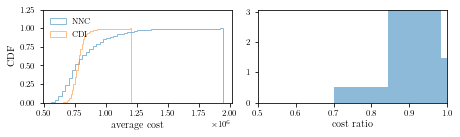

In [633]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns

# customized settings
params = {  # 'backend': 'ps',
    'font.family': 'serif',
    'font.serif': 'Latin Modern Roman',
    'font.size': 10,
    'axes.labelsize': 'medium',
    'axes.titlesize': 'medium',
    'legend.fontsize': 'medium',
    'xtick.labelsize': 'small',
    'ytick.labelsize': 'small',
    'savefig.dpi': 150,
    'text.usetex': True}
# tell matplotlib about your params
rcParams.update(params)

# set nice figure sizes
fig_width_pt = 469    # Get this from LaTeX using \showthe\columnwidth
golden_mean = (np.sqrt(5.) - 1.) / 2.  # Aesthetic ratio
ratio = golden_mean
inches_per_pt = 1. / 72.27  # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt  # width in inches
fig_height = fig_width*ratio  # height in inches
fig_size = [fig_width, 0.5*fig_height]
rcParams.update({'figure.figsize': fig_size})

fig, ax = plt.subplots(ncols=2)
#ax[0].text(0.02*(24-22)+22,0.88*1.25,r"(a)")
ax[0].hist(cost_nn,alpha=0.5,bins=50,density=True,label=r"NNC",histtype='step',cumulative=True)
ax[0].hist(cost_cdi,alpha=0.5,bins=50,density=True,label=r"CDI",histtype='step',cumulative=True)
#ax[0].set_xlim(22,24)
ax[0].set_ylim(0,1.25)
ax[0].set_xlabel(r"average cost")
ax[0].set_ylabel(r"CDF")
ax[0].legend(loc=2,fontsize=8,frameon=False)

#ax[1].text(0.02*(1.04-0.96)+0.96,0.88*40,r"(b)")
ax[1].hist(cost_ratios,bins=12,alpha=0.5,density=True)
ax[1].set_xlim(0.5,1)
#ax[1].set_ylim(0,40)
ax[1].set_xlabel(r"cost ratio")

plt.tight_layout()
plt.margins(0,0)
#plt.savefig("cost_comparison_capped_dual_index.png", dpi = 300, bbox_inches = 'tight', pad_inches = 0.05)
plt.show()

## Sample comparison

In [239]:
import plotly.express as px
from plotly import graph_objects as go

In [240]:
fixed_demands = state_trajectories[1, 1:, 1].unsqueeze(-1)
nn_inv, nn_qr, nn_qe, nn_ci, nn_mean_cost = evaluate_nnc_on_sample(state_trajectories, 5)
cdi_inv, cdi_qr, cdi_qe, cdi_ci, cdi_mean_cost = evaluate_cdi_on_sample(state_trajectories, qr_trajectories, qe_trajectories, 5)

In [241]:
a = go.Scatter(y=[x.item() for x in fixed_demands])
fig = go.Figure(a)
fig.layout.xaxis.title = 'Timestep'
fig.layout.yaxis.title = 'Demand'
fig

In [242]:
a = go.Scatter(y=[x.item() for x in nn_qr[1:]], name='NNC')
b = go.Scatter(y=cdi_qr, name='CDI')
fig = go.Figure([a,b])
fig.layout.xaxis.title = 'Timestep'
fig.layout.yaxis.title = 'Regular Order'
#fig.update_yaxes(range = [0,100])
fig

In [243]:
a = go.Scatter(y=[x.item() for x in nn_qe[1:]], name='NNC')
b = go.Scatter(y=cdi_qe, name='CDI')
fig = go.Figure([a,b])
fig.layout.xaxis.title = 'Timestep'
fig.layout.yaxis.title = 'Expedited Order'
fig

In [244]:
a = go.Scatter(y=[x.item() for x in nn_ci], name='NNC')
b = go.Scatter(y=[x.item() for x in cdi_ci], name='CDI')
fig = go.Figure([a,b])
fig.add_hline(nn_mean_cost.detach().item())
fig.add_hline(cdi_mean_cost.detach().item(),line={'dash':'dash'})
fig.layout.xaxis.title = 'Timestep'
fig.layout.yaxis.title = 'Cost'
fig

In [245]:
cdi_mean_cost.detach().item()

864635.3125

In [246]:
nn_mean_cost.detach().item()

903048.625

In [570]:
2.5e6*20/120

416666.6666666667

In [616]:
a = go.Scatter(y=nn_inv, name='NNC Inventory')
b = go.Scatter(y=cdi_inv, name='CDI Inventory')
c = go.Scatter(y=[x.detach().item() for x in fixed_demands], name='Demand',
               x=torch.arange(1, 1001).tolist() )
fig = go.Figure([a,b, c])
fig.layout.xaxis.title = 'Timestep'
fig.layout.yaxis.title = 'Quantity'
fig

In [244]:
1+1.7*1.5*20/120

1.425

In [268]:
1.425*1.7

2.4225